# Simulating a vesicle

## Overview

### Questions

* How do I include triangulated meshes in HOOMD?
* How can I apply mesh potenetials to the simulations?

### Objectives

- Create a spherical mesh and include it to the hoomd simulations.
- Run simulations at different area to volume ratios.

## Boilerplate Code

In [1]:
import math
import numpy
import IPython
import gsd.hoomd
import hoomd
import fresnel
import warnings
import packaging.version
from scipy.spatial import ConvexHull  


The `render` function in the next (hidden) cell will render a snapshot using **fresnel**. Find the source in the [hoomd-examples](https://github.com/glotzerlab/hoomd-examples) repository.

In [2]:
# This is not intended as a full tutorial on fresnel - see the fresnel user
# documentation (https://fresnel.readthedocs.io/) if you would like to learn more.

device = fresnel.Device()
tracer = fresnel.tracer.Path(device=device, w=300, h=300)

FRESNEL_MIN_VERSION = packaging.version.parse("0.13.0")
FRESNEL_MAX_VERSION = packaging.version.parse("0.14.0")


def render(snapshot):
    if ('version' not in dir(fresnel) or packaging.version.parse(
            fresnel.version.version) < FRESNEL_MIN_VERSION
            or packaging.version.parse(
                fresnel.version.version) >= FRESNEL_MAX_VERSION):
        warnings.warn(
            f"Unsupported fresnel version {fresnel.version.version} - expect errors."
        )
    central_color = fresnel.color.linear([252 / 255, 41 / 255, 0 / 255])

    L = snapshot.configuration.box[0]
    scene = fresnel.Scene(device)
    geometry = fresnel.geometry.Sphere(scene,
                                       N=len(snapshot.particles.position),
                                       radius=0.5)
    geometry.material = fresnel.material.Material(color=[0, 0, 0],
                                                  roughness=0.5,
                                                  primitive_color_mix=1.0)
    geometry.position[:] = snapshot.particles.position[:]
    geometry.color[snapshot.particles.typeid[:] == 0] = central_color
    geometry.radius[snapshot.particles.typeid[:] == 0] = 0.25
    geometry.outline_width = 0.01
    box = fresnel.geometry.Box(scene, [L, L, L, 0, 0, 0], box_radius=.02)

    scene.lights = [
        fresnel.light.Light(direction=(0, 0, 1),
                            color=(0.8, 0.8, 0.8),
                            theta=math.pi),
        fresnel.light.Light(direction=(1, 1, 1),
                            color=(1.1, 1.1, 1.1),
                            theta=math.pi / 3)
    ]
    scene.camera = fresnel.camera.Orthographic(position=(L * 2, L, L * 2),
                                               look_at=(0, 0, 0),
                                               up=(0, 1, 0),
                                               height=L * 1.4 + 1)
    scene.background_alpha = 1
    scene.background_color = (1, 1, 1)
    return IPython.display.Image(tracer.sample(scene, samples=500)._repr_png_())

### Simulation parameter

In [3]:
# Number of vertices in the mesh
N_mesh = 1600

# radius of the vesicle
R = 10
simseed = 1
kT = 0.2
gamma = 50

k_bend = 100
k_bond = 100
k_area = 1000
dt = 0.001

sigma = 1

### Creating the mesh using the Fibonacci sphere:

In [4]:
indices = numpy.arange(0, N_mesh, dtype=float) + 0.5

phi = numpy.arccos(1 - 2*indices/N_mesh)
theta = numpy.pi * (1 + 5**0.5) * indices

x, y, z = R * numpy.cos(theta) * numpy.sin(phi), R * numpy.sin(theta) * numpy.sin(phi), R * numpy.cos(phi)

vertex_positions = numpy.column_stack((x,y,z))

hull=ConvexHull(vertex_positions)
triangle_tags = hull.simplices

N_triangles = triangle_tags.shape[0]
for i in range(len(triangle_tags)):
    normal = numpy.cross(vertex_positions[triangle_tags[i,0]]-vertex_positions[triangle_tags[i,2]],vertex_positions[triangle_tags[i,0]]-vertex_positions[triangle_tags[i,1]])
    if numpy.dot(vertex_positions[triangle_tags[i,0]],normal) < 0:
        triangle_tags[i,1],triangle_tags[i,2] = triangle_tags[i,2],triangle_tags[i,1]

### Set up frame:

In [5]:
frame = gsd.hoomd.Frame()
frame.particles.N = N_mesh
frame.particles.position = vertex_positions
frame.particles.typeid = [0] * N_mesh
frame.configuration.box = [25, 25, 25, 0, 0, 0]
frame.particles.types = ['vertex']

### Create the Simulation Object

In [6]:
with gsd.hoomd.open(name='initial_mesh.gsd', mode='w') as f:
    f.append(frame)

In [7]:
CPU = hoomd.device.CPU()
sim = hoomd.Simulation(device=CPU, seed=simseed)
state = sim.create_state_from_gsd(filename='initial_mesh.gsd')

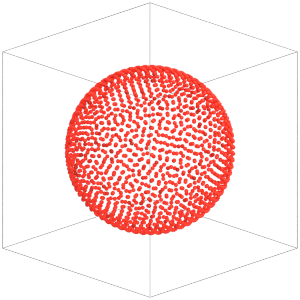

In [8]:
render(sim.state.get_snapshot())

### Set up Brownian integrator:

In [9]:
integrator = hoomd.md.Integrator(dt=dt)
sim.operations.integrator = integrator
filter_all = hoomd.filter.All()

brownian = hoomd.md.methods.Brownian(filter=filter_all, kT=kT)
brownian.gamma.default = gamma
integrator.methods.append(brownian)

### Initialize mesh object:

The mesh object is defined by the triangulation. Each triangle is assigned the triangle type `mesh`

In [10]:
mesh_obj = hoomd.mesh.Mesh()
mesh_obj.types = ["mesh"]
mesh_obj.triangulation = dict(type_ids = [0] * N_triangles,
      triangles = triangle_tags)

## Add mesh potentials

### The tether potential

The bond potentials act on all vertex pairs connected with an edge. For some of the bond potentials, such as the tethering potential, the mesh edge lengths must lie between `l_min` and `l_max`. Hence it is important to check the minimal and maximal edge lengths to avoid out of bound errors.

![Helfrich-Plot](Helfrich_plot.svg)

In [11]:
# Define tether parameter
l_min=(2/3)*sigma
l_c1=0.85*sigma
l_c0=1.15*sigma
l_max=(4/3)*sigma 

# check that edge lengths are in the tether window
triangle_cartesian_positions = frame.particles.position[triangle_tags]
global_max_edge = numpy.linalg.norm(triangle_cartesian_positions[:,0]-triangle_cartesian_positions[:,1],axis=1).max()
global_min_edge = numpy.linalg.norm(triangle_cartesian_positions[:,0]-triangle_cartesian_positions[:,1],axis=1).min()
global_mean = numpy.linalg.norm(triangle_cartesian_positions[:,0]-triangle_cartesian_positions[:,1],axis=1).mean()

global_max_edge,global_min_edge,global_mean

(1.2657272, 0.77298886, 0.98328316)

### Add bond potential to mesh

In [12]:
mesh_bond_potential = hoomd.md.mesh.bond.Tether(mesh_obj)
mesh_bond_potential.params["mesh"] = dict(k_b=k_bond, l_min=l_min, l_c1=l_c1, l_c0=l_c0, l_max=l_max)
integrator.forces.append(mesh_bond_potential)

### WCA potential between vertices

To avoid self-intersections of the mesh we can apply a pair interactions between the vertices. However, by passing the `mesh_obj` to a neighbor list we can exclude vertices within the same triangle.

In [13]:
cell = hoomd.md.nlist.Cell(buffer=0.4, mesh=mesh_obj, exclusions=('meshbond',))

lj = hoomd.md.pair.LJ(nlist=cell,mode="shift")
lj.params[('vertex','vertex')] = dict(epsilon=1, sigma=sigma)
lj.r_cut[('vertex','vertex')] = 2**(1.0/6.)*sigma
integrator.forces.append(lj)

### Add bending potential to mesh (Helfrich bending potential)

In [14]:
helfrich_rigidity = hoomd.md.mesh.bending.Helfrich(mesh_obj)
helfrich_rigidity.params["mesh"] = dict(k=k_bend)
integrator.forces.append(helfrich_rigidity)

### Area conservation of triangle mesh

In [15]:
Area = 4 * numpy.pi * R**2
area_potential = hoomd.md.mesh.conservation.Area(mesh_obj)
area_potential.params["mesh"] = dict(k=k_area,A0=Area)
integrator.forces.append(area_potential)

### Run the Simulation!

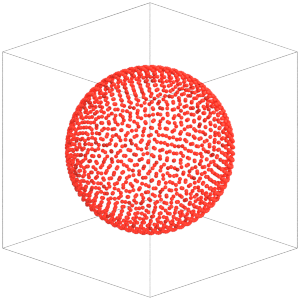

In [16]:
sim.run(0)
render(sim.state.get_snapshot())

[0.99654918]


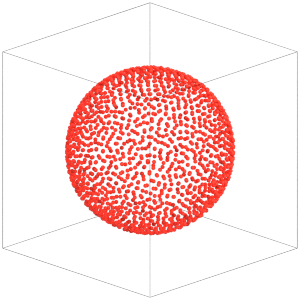

In [17]:
sim.run(20000)
print(area_potential.area/Area)
render(sim.state.get_snapshot())

### Volume conservation of triangle mesh

In [18]:
Volume = 4/3 * numpy.pi * R**3
volume_potential = hoomd.md.mesh.conservation.Volume(mesh_obj)
volume_potential.params["mesh"] = dict(k=1000,V0=Volume)
integrator.forces.append(volume_potential)

[0.99908716]


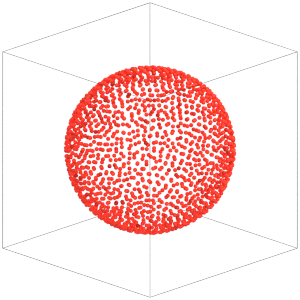

In [19]:
sim.run(10000)
print(volume_potential.volume/Volume)
render(sim.state.get_snapshot())

### Define volume updater

To change the volume constraint during the simulation we create a volume updater. For more information about updaters see [Custom Actions in Python](../04-Custom-Actions-In-Python/00-index.ipynb).

In [20]:
class UpdateVolume(hoomd.custom.Action):
    def __init__(self, volume_potential, volume):
        self._volume_potential= volume_potential
        self._volume = volume

    @property
    def volume(self):
        """A `hoomd.variant.Variant` object."""
        return self._volume

    @volume.setter
    def volume(self, new_volume):
        if isinstance(new_volume, numbers.Number):
            self._volume = hoomd.variant.Constant(new_volume)
        elif isinstance(new_volume, hoomd.variant.Variant):
            self._volume = new_volume
        else:
            message = "volume must be a variant or real number."
            raise ValueError(message)

    def act(self, timestep):
        self._volume_potential.params["mesh"] = dict(k=1000,V0=self.volume(timestep))

### Initialize volume updater

In [21]:
volume_variant = hoomd.variant.Ramp(A=Volume, B=0.8*Volume, t_start=30000, t_ramp=130000)

volume_operation = hoomd.update.CustomUpdater(
    action=UpdateVolume(volume_potential,volume_variant), trigger=100)

sim.operations.updaters.append(volume_operation)

### Run simulation with changing volume constraint

40000 [0.9862508]
50000 [0.9725496]
60000 [0.95885795]
70000 [0.94478571]
80000 [0.93104517]
90000 [0.91688198]
100000 [0.90150326]
110000 [0.88393071]
120000 [0.86685178]
130000 [0.85089874]


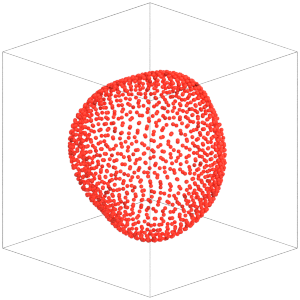

In [22]:
for _ in range(10):
    sim.run(10000)
    print(sim.timestep,volume_potential.volume/Volume)
render(sim.state.get_snapshot())
